<a href="https://colab.research.google.com/github/edusgr/EDP-II/blob/main/Metropolis_Hastings.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Explique en qué consiste el algoritmo de Metrópolis-Hastings y porque funciona**



El algoritmo presenta un método Monte Carlo basado fuertemente en la teoría de Cadenas de Markov con el objetivo de obtener muestras aproximadas de una distribución de probabilidad compleja. Su fortaleza es que puede implementarse cuando no es posible hacer un muestreo directo sobre la función de distribución de probabilidad, es decir que la función a la que se desea llegar es multidimensional o compleja de normalizar, aunque también es muy útil en la inferencia bayesiana.


El enfoque toma una fuerte base en los procesos estocásticos específicamente en las cadenas de Markov, entonces el objetivo es construir una cadena de Markov fácil de simular cuya distribución estacionaria es precisamente la distribución que deseamos muestrear.


**Por ejemplo:**

**Consideremos una cadena discreta con matriz de transición $P$**

$$
P=\begin{pmatrix} 0.2 &0.8 \\0.1 & 0.9 \end{pmatrix}
\\[2ex]
$$



Ya que en una cadena de Markov se pueden hacer preguntas como “¿En qué estado estoy?”, “¿Cuál es la probabilidad de cambiar de estado?”, también es posible preguntarse “¿Cuál es la probabilidad de estar en un estado dado que ya ha pasado mucho tiempo?”



Para este ejemplo solo tenemos 2 estados, por lo que esa distribución de probabilidad es un vector de 2 dimensiones.

$$
\pi=(\pi_0 , \pi_1)
$$

donde tenemos lo siguiente:

$$
\pi_0 = P[X=0]
$$

$$
\pi_1 = P[X=1]
$$

Intuitivamente podríamos decir que

 $$\pi=(proba\;de\;estar\;en\;0,\;\; proba\;de\;estar\;en\;1)$$


Este tipo de distribuciones estacionarias cumple la siguiente propiedad:

$$
 \pi = \pi P
$$

Por lo que para este ejemplo tendríamos lo siguiente:

$$
(\pi_0, \pi_1)= (\pi_0, \pi_1)\begin{pmatrix} 0.2 &0.8 \\0.1 & 0.9 \end{pmatrix}
$$

$$
(\pi_0, \pi_1)=0.2 \pi_0 + 0.1 \pi_1, 0.8 \pi_0 + 0.9 \pi_1
\\[2ex]
$$

$$
\pi_0 = 0.2 \pi_0 + 0.1 \pi_1
$$

$$
\pi_1 = 0.8 \pi_0 + 0.9 \pi_1
$$

Resolviendo el sistema llegamos a lo siguiente:

$$
\pi_0 = \frac{1}{9}
$$

$$
\pi_1 = \frac{8}{9}
$$

$$
\pi = \left( \frac{1}{9} , \frac{8}{9} \right)
$$

Es decir que cuando ya ha pasado mucho tiempo, no importa en qué estado inicie la cadena, siempre la cadena tendrá la siguiente distribución estacionaria:

$$
P[X=0]=\frac{1}{9} \;\;\;\;\;\; P[X=1]=\frac{8}{9}
$$

### **Relación con Metrópolis-Hastings**

En particular, el algoritmo calcula el estado de la cadena de Markov en el tiempo $t+1$. Se propone un valor de la variable aleatoria $Y$, que debe ser generado a través de una distribución $q(\;\cdot \;|X_t )$, la cual solo depende del estado $X_t$.



Muy a menudo se toma a $q$ como una distribución normal multivariada centrada en $X_t$ con matriz de covarianzas $\Sigma$. Esto porque recordemos que parte de la idea de Metrópolis-Hastings es que la distribución sea fácil de simular para realizar un número considerable de iteraciones.



A partir del valor actual $X_t$, el algoritmo propone un nuevo valor candidato $Y$, generado mediante una distribución propuesta $q(\;\cdot \;|X_t )$. Después se calcula la probabilidad de aceptación:


$$
\alpha(X_t,Y)=
\min\left\{
1,
\frac{\pi(Y)q(X_t|Y)}
{\pi(X_t)q(Y|X_t)}
\right\}
$$

donde $\pi(X)$ es la distribución objetivo que se desea muestrear y $q(Y|X_t)$ es la distribución propuesta que cumple con las condiciones de regularidad.

1. **Irreducibilidad:** Existe una probabilidad positiva de que la cadena llegue a cualquier estado a partir de cualquier otro estado inicial.
2. **Aperiodicidad:** La cadena no varía entre diferentes conjuntos de estados.

Después se genera un número aleatorio:

$$
U\sim U(0,1)\;\;\;
Si:\;\;\;
U\leq \alpha(X_t,Y)
$$

entonces se acepta el candidato y se define:

$$
X_{t+1}=Y
$$

En caso contrario, se rechaza el candidato y la cadena permanece en el mismo estado:

$$
X_{t+1}=X_t
$$

### **Caso de la distribución simétrica**

Si la propuesta de distribución es una distribución simétrica, vamos a tener las siguientes características:

$$
q(Y|X_t)=q(X_t|Y)
$$

por lo que la probabilidad de aceptación se simplifica a:

$$
\alpha(X_t,Y)=
\min\left\{
1,
\frac{\pi(Y)}{\pi(X_t)}
\right\}
$$

Esto ocurre, por ejemplo, cuando se usa una distribución normal centrada en el valor actual:

$$
Y=X_t+\sigma Z,\qquad Z\sim N(0,1)
$$

Entonces este algoritmo funciona porque la forma en la que acepta o rechaza candidatos hace que la cadena de Markov tenga como distribución estacionaria a la distribución objetivo. Es decir, después de muchas iteraciones, los valores generados por la cadena se distribuyen aproximadamente como la distribución que se desea simular.

La idea central es que los movimientos hacia zonas de mayor probabilidad se aceptan con facilidad, pero también se permite aceptar algunos movimientos hacia zonas de menor probabilidad. Esto permite que la cadena explore el espacio de posibles valores y no se quede atrapada en una sola región.

### **Consideraciones de este método**

Los primeros valores generados por la cadena suelen presentar una alta correlación entre sí. Esto contrasta con el método de Aceptación-Rechazo, en el cual las muestras obtenidas son independientes. Debido a esta dependencia inicial, es posible que los primeros estados de la cadena todavía no representen adecuadamente la distribución objetivo. Por esta razón, en el análisis inferencial se suelen descartar las primeras observaciones, por ejemplo las primeras 1000 iteraciones. A este proceso se le conoce como periodo de calentamiento, burn-in o quemado.


Por otro lado, métodos como Aceptación-Rechazo pueden verse afectados por la llamada maldición de la dimensionalidad, ya que conforme aumenta el número de variables, la probabilidad de rechazo puede crecer considerablemente. En cambio, el método de Metrópolis-Hastings y otros algoritmos de Monte Carlo basados en cadenas de Markov suelen ser más adecuados para trabajar con distribuciones de alta dimensión, por lo que son ampliamente utilizados en este tipo de problemas.




### **Resumen del algoritmo**

Podemos sintetizar el algoritmo a los siguientes pasos:

1. Asignar un valor inicial a $X_t$.
2. Dar $t=0$.
3. Generar $Y \sim q(Y|X_t)$.
4. Definir:

$$
\alpha(X_t,Y)=
\min\left\{
1,
\frac{\pi(Y)q(X_t|Y)}
{\pi(X_t)q(Y|X_t)}
\right\}
$$

5. Hacer $X_{t+1}=Y$ con probabilidad $\alpha(X_t, Y)$ o, en caso contrario, $X_{t+1}=X_t$.
6. $t=t+1$ y volver al paso 3.



## **Genere valores para una distribución usando el algoritmo de Metrópolis-Hastings.**



Para aplicar el algoritmo de Metrópolis-Hastings se generarán valores de una distribución Gamma con parámetros $\alpha=2$ y $\lambda=1$, cuya función de densidad está dada por:

$$
f(x)=xe^{-x}, \qquad x>0
$$

En este caso se toma como distribución objetivo:

$$
\pi(x)=xe^{-x}
$$

y se define $\pi(x)=0$ cuando $x\leq 0$, ya que la distribución Gamma solo toma valores positivos.

Como distribución propuesta se utiliza una caminata aleatoria normal:

$$
Y=X_t+\sigma Z
$$

donde:

$$
Z\sim N(0,1)
$$

Como esta propuesta es simétrica, la probabilidad de aceptación se simplifica a:

$$
\alpha(X_t,Y)=
\min\left\{
1,
\frac{\pi(Y)}{\pi(X_t)}
\right\}
$$

Después de generar la cadena, se eliminan las primeras observaciones mediante un periodo de burn-in, ya que los primeros valores pueden depender mucho del punto inicial.

## **Código**


Primero importamos librerías:

In [25]:
from random import random
from math import log, sqrt, exp, pi, cos
import numpy as np
import matplotlib.pyplot as plt

Ahora creamos un generador de normales estándar con Box-Muller, usando random()

In [26]:
def normal_estandar():
    u1 = random()
    u2 = random()

    z = sqrt(-2*log(u1))*cos(2*pi*u2)

    return z

Definimos la distribución objetivo:

In [27]:
def pi_objetivo(x):

    if x <= 0:
        return 0
    else:
        return x*exp(-x)

Ahora programamos el algoritmo de Metrópolis-Hastings:

In [28]:
def metropolis_hastings(n, sigma):

    x = np.zeros(n)

    # Valor inicial positivo
    x[0] = 1

    aceptados = 0

    for t in range(1, n):

        # Propuesta
        y = x[t-1] + sigma*normal_estandar()

        # Probabilidad de aceptación
        alpha = min(1, pi_objetivo(y)/pi_objetivo(x[t-1]))

        # Número aleatorio uniforme
        u = random()

        # Aceptar o rechazar
        if u <= alpha:
            x[t] = y
            aceptados = aceptados + 1
        else:
            x[t] = x[t-1]

    tasa_aceptacion = aceptados/(n-1)

    return x, tasa_aceptacion

Corremos la simulación:

In [29]:
n = 10000
sigma = 1

valores, tasa = metropolis_hastings(n, sigma)

print("Media simulada:", np.mean(valores))
print("Desviación estándar simulada:", np.std(valores))
print("Tasa de aceptación:", tasa)

Media simulada: 1.8998896943281867
Desviación estándar simulada: 1.293324176474907
Tasa de aceptación: 0.7168716871687169


Aplicamos el concepto de burn-in (este paso podría omitirse):

In [30]:
burn_in = 1000

valores_burn = valores[burn_in:]

print("Media después del burn-in:", np.mean(valores_burn))
print("Desviación estándar después del burn-in:", np.std(valores_burn))
print("Tasa de aceptación:", tasa)

Media después del burn-in: 1.9319713617049477
Desviación estándar después del burn-in: 1.313097989268573
Tasa de aceptación: 0.7168716871687169


Graficamos para ver cómo se mueve la cadena generada:

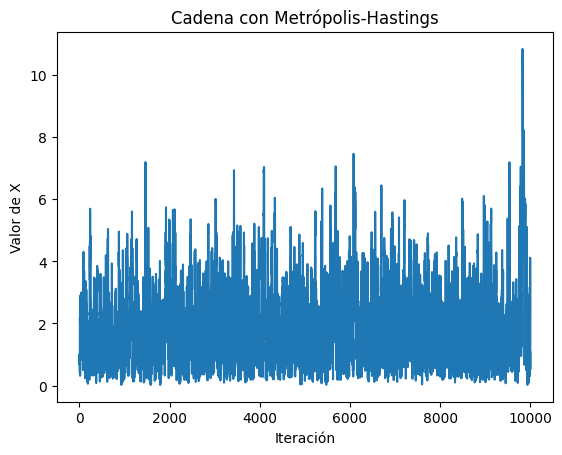

In [31]:
plt.plot(valores)
plt.title("Cadena con Metrópolis-Hastings")
plt.xlabel("Iteración")
plt.ylabel("Valor de X")
plt.show()

Generamos un histograma para compararlo con la densidad teórica:

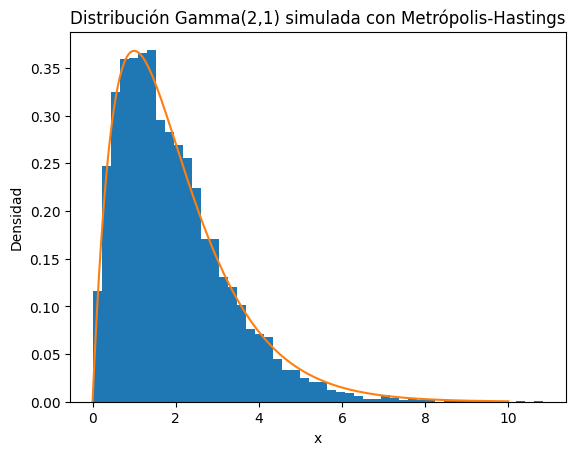

In [32]:
x_teorica = np.linspace(0, 10, 200)
y_teorica = x_teorica*np.exp(-x_teorica)

plt.hist(valores_burn, bins=50, density=True)
plt.plot(x_teorica, y_teorica)
plt.title("Distribución Gamma(2,1) simulada con Metrópolis-Hastings")
plt.xlabel("x")
plt.ylabel("Densidad")
plt.show()

### **Conclusiones de resultados**

Después de realizar la simulación, se observa que los valores generados se concentran principalmente en valores positivos, como corresponde a una distribución Gamma. Además, al comparar el histograma con la función teórica $f(x)=xe^{-x}$, se observa que la forma de la distribución simulada es similar a la distribución objetivo.

La media teórica de una distribución $\;\;\Gamma(2,1)$ es:

$$
E[X]=2
$$

mientras que su desviación estándar teórica es:
$$
\sigma=\sqrt{2}\approx 1.4142
$$

Por lo tanto, si la media simulada se aproxima a 2 y la desviación estándar se aproxima a 1.4142, se puede considerar que el algoritmo generó valores adecuados de la distribución objetivo.

Lo cual se cumplio al correr esta simulación